# RF-DETR-S person fine-tuning (pool footage)

Inputs, in Drive folder `MyDrive/RT_DETR_S finetuning`:
- `images/` raw frames
- `gt_boxes.json` person boxes per frame (x, y = top-left, width, height in pixels)
- `images_labeled/` frames with the boxes drawn, for visual checks only (never trained on)

In [17]:
# 1. Import packages
from importlib.metadata import version
from rfdetr import RFDETRSmall
import cv2
print("rfdetr", version("rfdetr"), "| cv2", cv2.__version__)

rfdetr 1.11.0 | cv2 5.0.0


In [7]:
# 2. Mount Drive and copy the dataset to the local disk (reading from Drive during training is slow)
import shutil
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")
DRIVE_DIR = Path("/content/drive/MyDrive/RT_DETR_S finetuning")
DRIVE_OUT = DRIVE_DIR / "outputs"

# the dataset folder is the one holding gt_boxes.json (DRIVE_DIR itself or a subfolder)
found = sorted(p.parent for p in DRIVE_DIR.rglob("gt_boxes.json") if "outputs" not in p.parts)
assert found, f"gt_boxes.json not found under {DRIVE_DIR}"
SRC = found[0]
print("dataset on Drive:", SRC)

DATA = Path("/content/aquaperson_wavepool_v1")
WORK = Path("/content")
shutil.rmtree(DATA, ignore_errors=True)
shutil.copytree(SRC, DATA, ignore=shutil.ignore_patterns("*.ipynb", "outputs"))
print(len(list((DATA / "images").glob("*.jpg"))), "images copied to", DATA)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dataset on Drive: /content/drive/MyDrive/RT_DETR_S finetuning
80 images copied to /content/aquaperson_wavepool_v1


80 labeled frames, 3173 person boxes


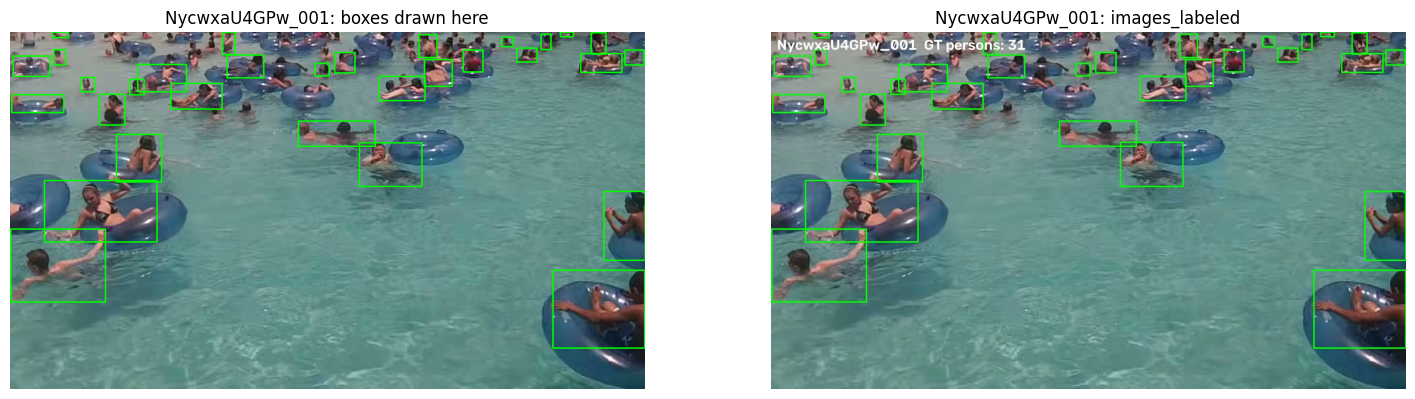

In [8]:
# 3. Check labels against images and look at one frame
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np

GT = {Path(k).stem: v for k, v in json.loads((DATA / "gt_boxes.json").read_text())["images"].items()}


def read_gt(stem):
    b = GT[stem]["boxes"]
    if not b:
        return np.zeros((0, 4), np.float32)
    return np.array([[x["x"], x["y"], x["x"] + x["width"], x["y"] + x["height"]] for x in b], np.float32)


def draw(img, boxes, color):
    out = img.copy()
    for x1, y1, x2, y2 in boxes.astype(int):
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
    return out


labeled = sorted(GT)
missing = [s for s in labeled if not (DATA / "images" / f"{s}.jpg").exists()]
assert not missing, f"boxes without an image: {missing}"
for s in labeled:
    h, w = cv2.imread(str(DATA / "images" / f"{s}.jpg")).shape[:2]
    assert (w, h) == (GT[s]["image_width"], GT[s]["image_height"]), f"size mismatch: {s}"
print(f"{len(labeled)} labeled frames, {sum(len(read_gt(s)) for s in labeled)} person boxes")

s = labeled[0]
raw = cv2.imread(str(DATA / "images" / f"{s}.jpg"))
mine = draw(raw, read_gt(s), (0, 255, 0))
vis_path = DATA / "images_labeled" / f"{s}.jpg"
panels = [("boxes drawn here", mine)] + ([("images_labeled", cv2.imread(str(vis_path)))] if vis_path.exists() else [])
fig, axes = plt.subplots(1, len(panels), figsize=(9 * len(panels), 6), squeeze=False)
for ax, (title, im) in zip(axes[0], panels):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax.set_title(f"{s}: {title}"); ax.axis("off")
plt.show()

In [9]:
# 4. Train / valid split and RF-DETR dataset folder (YOLO format)
# Neighbouring frames are near-duplicates, so hold out a contiguous block per video
# (or a whole video) instead of random frames. GAP frames between train and valid are dropped.
import math
import re
import shutil
from collections import defaultdict

VAL_FRAC = 0.2
GAP = 2
HOLDOUT_VIDEO = None  # e.g. "UaFwQMfQThE" once frames from both videos are labeled

by_video = defaultdict(list)
for s in labeled:
    vid, idx = re.match(r"(.+)_(\d+)$", s).groups()
    by_video[vid].append((int(idx), s))

split = {"train": [], "valid": []}
for vid, frames in by_video.items():
    stems = [s for _, s in sorted(frames)]
    if HOLDOUT_VIDEO:
        split["valid" if vid == HOLDOUT_VIDEO else "train"] += stems
        continue
    n_val = max(1, math.ceil(len(stems) * VAL_FRAC))
    split["valid"] += stems[-n_val:]
    split["train"] += stems[:max(0, len(stems) - n_val - GAP)]

DS = WORK / "ds"
shutil.rmtree(DS, ignore_errors=True)
for name, stems in split.items():
    for sub in ("images", "labels"):
        (DS / name / sub).mkdir(parents=True)
    for s in stems:
        shutil.copy(DATA / "images" / f"{s}.jpg", DS / name / "images")
        w, h = GT[s]["image_width"], GT[s]["image_height"]
        lines = [f"0 {(x1 + x2) / 2 / w:.6f} {(y1 + y2) / 2 / h:.6f} {(x2 - x1) / w:.6f} {(y2 - y1) / h:.6f}"
                 for x1, y1, x2, y2 in read_gt(s)]
        (DS / name / "labels" / f"{s}.txt").write_text("\n".join(lines) + ("\n" if lines else ""))
(DS / "data.yaml").write_text("train: train/images\nval: valid/images\nnc: 1\nnames: ['person']\n")
val_stems = split["valid"]
print({k: len(v) for k, v in split.items()}, "| valid:", val_stems[0], "...", val_stems[-1])

{'train': 62, 'valid': 16} | valid: NycwxaU4GPw_065 ... NycwxaU4GPw_080


In [10]:
# 5. Evaluation helpers + zero-shot baseline (pretrained COCO RF-DETR-S, no fine-tuning)
import contextlib
import io

from PIL import Image
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from rfdetr import RFDETRSmall

EVAL_CONF = 0.05  # low threshold so AP sees the full score range
OP_CONF = 0.25    # operating threshold for precision / recall


def predict(model, img_bgr, person_id, thr=EVAL_CONF):
    d = model.predict(Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)), threshold=thr)
    k = np.ones(len(d), bool) if person_id is None else d.class_id == person_id
    return d.xyxy[k], d.confidence[k]


def iou(a, b):
    x1, y1 = np.maximum(a[:, None, 0], b[None, :, 0]), np.maximum(a[:, None, 1], b[None, :, 1])
    x2, y2 = np.minimum(a[:, None, 2], b[None, :, 2]), np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    area = lambda z: (z[:, 2] - z[:, 0]) * (z[:, 3] - z[:, 1])
    return inter / (area(a)[:, None] + area(b)[None, :] - inter + 1e-9)


def greedy_tp(pred, scores, gt, thr=0.5):
    if not len(pred) or not len(gt):
        return 0
    m, used, tp = iou(pred[np.argsort(-scores)], gt), set(), 0
    for row in m:
        j = next((j for j in np.argsort(-row) if row[j] >= thr and j not in used), None)
        if j is not None:
            used.add(j); tp += 1
    return tp


def evaluate(model, stems, person_id, name):
    images, anns, dets, tp, n_pred, n_gt = [], [], [], 0, 0, 0
    for i, s in enumerate(stems, 1):
        img = cv2.imread(str(DATA / "images" / f"{s}.jpg"))
        h, w = img.shape[:2]
        gt = read_gt(s)
        pb, ps = predict(model, img, person_id)
        images.append({"id": i, "width": w, "height": h, "file_name": s})
        for b in gt:
            anns.append({"id": len(anns) + 1, "image_id": i, "category_id": 1, "iscrowd": 0,
                         "bbox": [float(b[0]), float(b[1]), float(b[2] - b[0]), float(b[3] - b[1])],
                         "area": float((b[2] - b[0]) * (b[3] - b[1]))})
        for b, c in zip(pb, ps):
            dets.append({"image_id": i, "category_id": 1, "score": float(c),
                         "bbox": [float(b[0]), float(b[1]), float(b[2] - b[0]), float(b[3] - b[1])]})
        op = ps >= OP_CONF
        tp += greedy_tp(pb[op], ps[op], gt); n_pred += int(op.sum()); n_gt += len(gt)
    with contextlib.redirect_stdout(io.StringIO()):
        coco = COCO(); coco.dataset = {"images": images, "annotations": anns, "categories": [{"id": 1, "name": "person"}]}
        coco.createIndex()
        ev = COCOeval(coco, coco.loadRes(dets) if dets else COCO(), "bbox")
        ev.params.maxDets = [100, 300, 300]
        ev.evaluate(); ev.accumulate(); ev.summarize()
    p, r = tp / max(n_pred, 1), tp / max(n_gt, 1)
    res = {"model": name, "AP50": round(float(ev.stats[1]), 3), "AP50_95": round(float(ev.stats[0]), 3),
           "precision@0.25": round(p, 3), "recall@0.25": round(r, 3),
           "F1": round(2 * p * r / max(p + r, 1e-9), 3), "gt_boxes": n_gt}
    print(res)
    return res


base = RFDETRSmall()
res_base = evaluate(base, val_stems, person_id=1, name="pretrained RF-DETR-S")  # COCO id 1 = person

[2026-09-27 04:31:03] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-small.pth


/root/.roboflow/models/rf-detr-small.pth:   0%|          | 0.00/368M [00:00<?, ?iB/s]

[2026-09-27 04:31:08] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-small.pth


[2026-09-27 04:31:08] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-27 04:31:08] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-27 04:31:09] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-small.pth already exists with correct MD5 hash.


[2026-09-27 04:31:11] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


{'model': 'pretrained RF-DETR-S', 'AP50': 0.569, 'AP50_95': 0.321, 'precision@0.25': 0.754, 'recall@0.25': 0.266, 'F1': 0.393, 'gt_boxes': 680}


In [11]:
# 6. Fine-tune RF-DETR-S
# RESOLUTION must be a multiple of 32; 512 is the pretrained size. 640 helps small people but uses more memory.
OUT = WORK / "runs" / "rfdetr_s_person"
RESOLUTION = 512

model = RFDETRSmall()
model.train(
    dataset_dir=str(DS),
    output_dir=str(OUT),
    resolution=RESOLUTION,
    epochs=80,
    batch_size=4,
    grad_accum_steps=2,
    lr=1e-4,
    early_stopping=True,
    early_stopping_patience=15,
)
!ls -la {OUT}

[2026-09-27 04:31:30] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-small.pth already exists with correct MD5 hash.


[2026-09-27 04:31:30] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-27 04:31:30] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-27 04:31:32] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-small.pth already exists with correct MD5 hash.


[2026-09-27 04:31:34] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-27 04:31:34] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-27 04:31:35] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-small.pth already exists with correct MD5 hash.


...

[2026-09-27 04:37:52] [INFO] rf-detr - Best EMA metric improved to 0.5076 (epoch 23)


INFO:pytorch_lightning.callbacks.early_stopping:Metric __rfdetr_effective_map__ improved by 0.005 >= min_delta = 0.001. New best score: 0.512


[2026-09-27 04:38:24] [INFO] rf-detr - Best EMA metric improved to 0.5122 (epoch 25)


INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric __rfdetr_effective_map__ did not improve in the last 15 records. Best score: 0.512. Signaling Trainer to stop.


[2026-09-27 04:42:21] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.0000, ema=0.5122)
total 2861392
drwxr-xr-x 2 root root      4096 Sep 27 04:42 .
drwxr-xr-x 3 root root      4096 Sep 27 04:31 ..
-rw-r--r-- 1 root root 509494928 Sep 27 04:36 checkpoint_19.ckpt
-rw-r--r-- 1 root root 509494928 Sep 27 04:39 checkpoint_29.ckpt
-rw-r--r-- 1 root root 509494928 Sep 27 04:42 checkpoint_39.ckpt
-rw-r--r-- 1 root root 509494928 Sep 27 04:34 checkpoint_9.ckpt
-rw-r--r-- 1 root root 127491849 Sep 27 04:38 checkpoint_best_ema.pth
-rw------- 1 root root 127479729 Sep 27 04:42 checkpoint_best_total.pth
-rw-r--r-- 1 root root     55573 Sep 27 04:42 events.out.tfevents.1790483500.440c5e7b067e.1772.0
-rw-r--r-- 1 root root         3 Sep 27 04:31 hparams.yaml
-rw-r--r-- 1 root root 509495056 Sep 27 04:42 last.ckpt
-rw-r--r-- 1 root root 127486488 Sep 27 04:42 last_ema.pth
-rw-r--r-- 1 root root     19258 Sep 27 04:42 metrics.csv
-rw------- 1 root root      4067 Sep 27 04:42 training

In [12]:
# 7. Evaluate the fine-tuned checkpoint on the same valid frames
import pandas as pd

ft = RFDETRSmall.from_checkpoint(str(OUT / "checkpoint_best_total.pth"))
res_ft = evaluate(ft, val_stems, person_id=None, name="fine-tuned RF-DETR-S")  # single-class model, keep every box
pd.DataFrame([res_base, res_ft]).set_index("model")

/usr/local/lib/python3.13/dist-packages/rfdetr/detr.py:704: FutureWarning: The `RFDETRBase` was deprecated since v1.7.0. It will be removed in v2.0.0.
  getattr(variant_obj, "__name__", symbol): variant_obj
/usr/local/lib/python3.13/dist-packages/rfdetr/detr.py:704: FutureWarning: The `RFDETRLargeDeprecated` was deprecated since v1.7.0. It will be removed in v2.0.0.
  getattr(variant_obj, "__name__", symbol): variant_obj
/usr/local/lib/python3.13/dist-packages/rfdetr/detr.py:704: FutureWarning: The `RFDETRSegPreview` was deprecated since v1.7.0. It will be removed in v2.0.0.
  getattr(variant_obj, "__name__", symbol): variant_obj
[2026-09-27 04:42:22] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-27 04:42:22] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is

{'model': 'fine-tuned RF-DETR-S', 'AP50': 0.809, 'AP50_95': 0.504, 'precision@0.25': 0.675, 'recall@0.25': 0.838, 'F1': 0.748, 'gt_boxes': 680}


,AP50,AP50_95,precision@0.25,recall@0.25,F1,gt_boxes
model,,,,,,
pretrained RF-DETR-S,0.569,0.321,0.754,0.266,0.393,680
fine-tuned RF-DETR-S,0.809,0.504,0.675,0.838,0.748,680


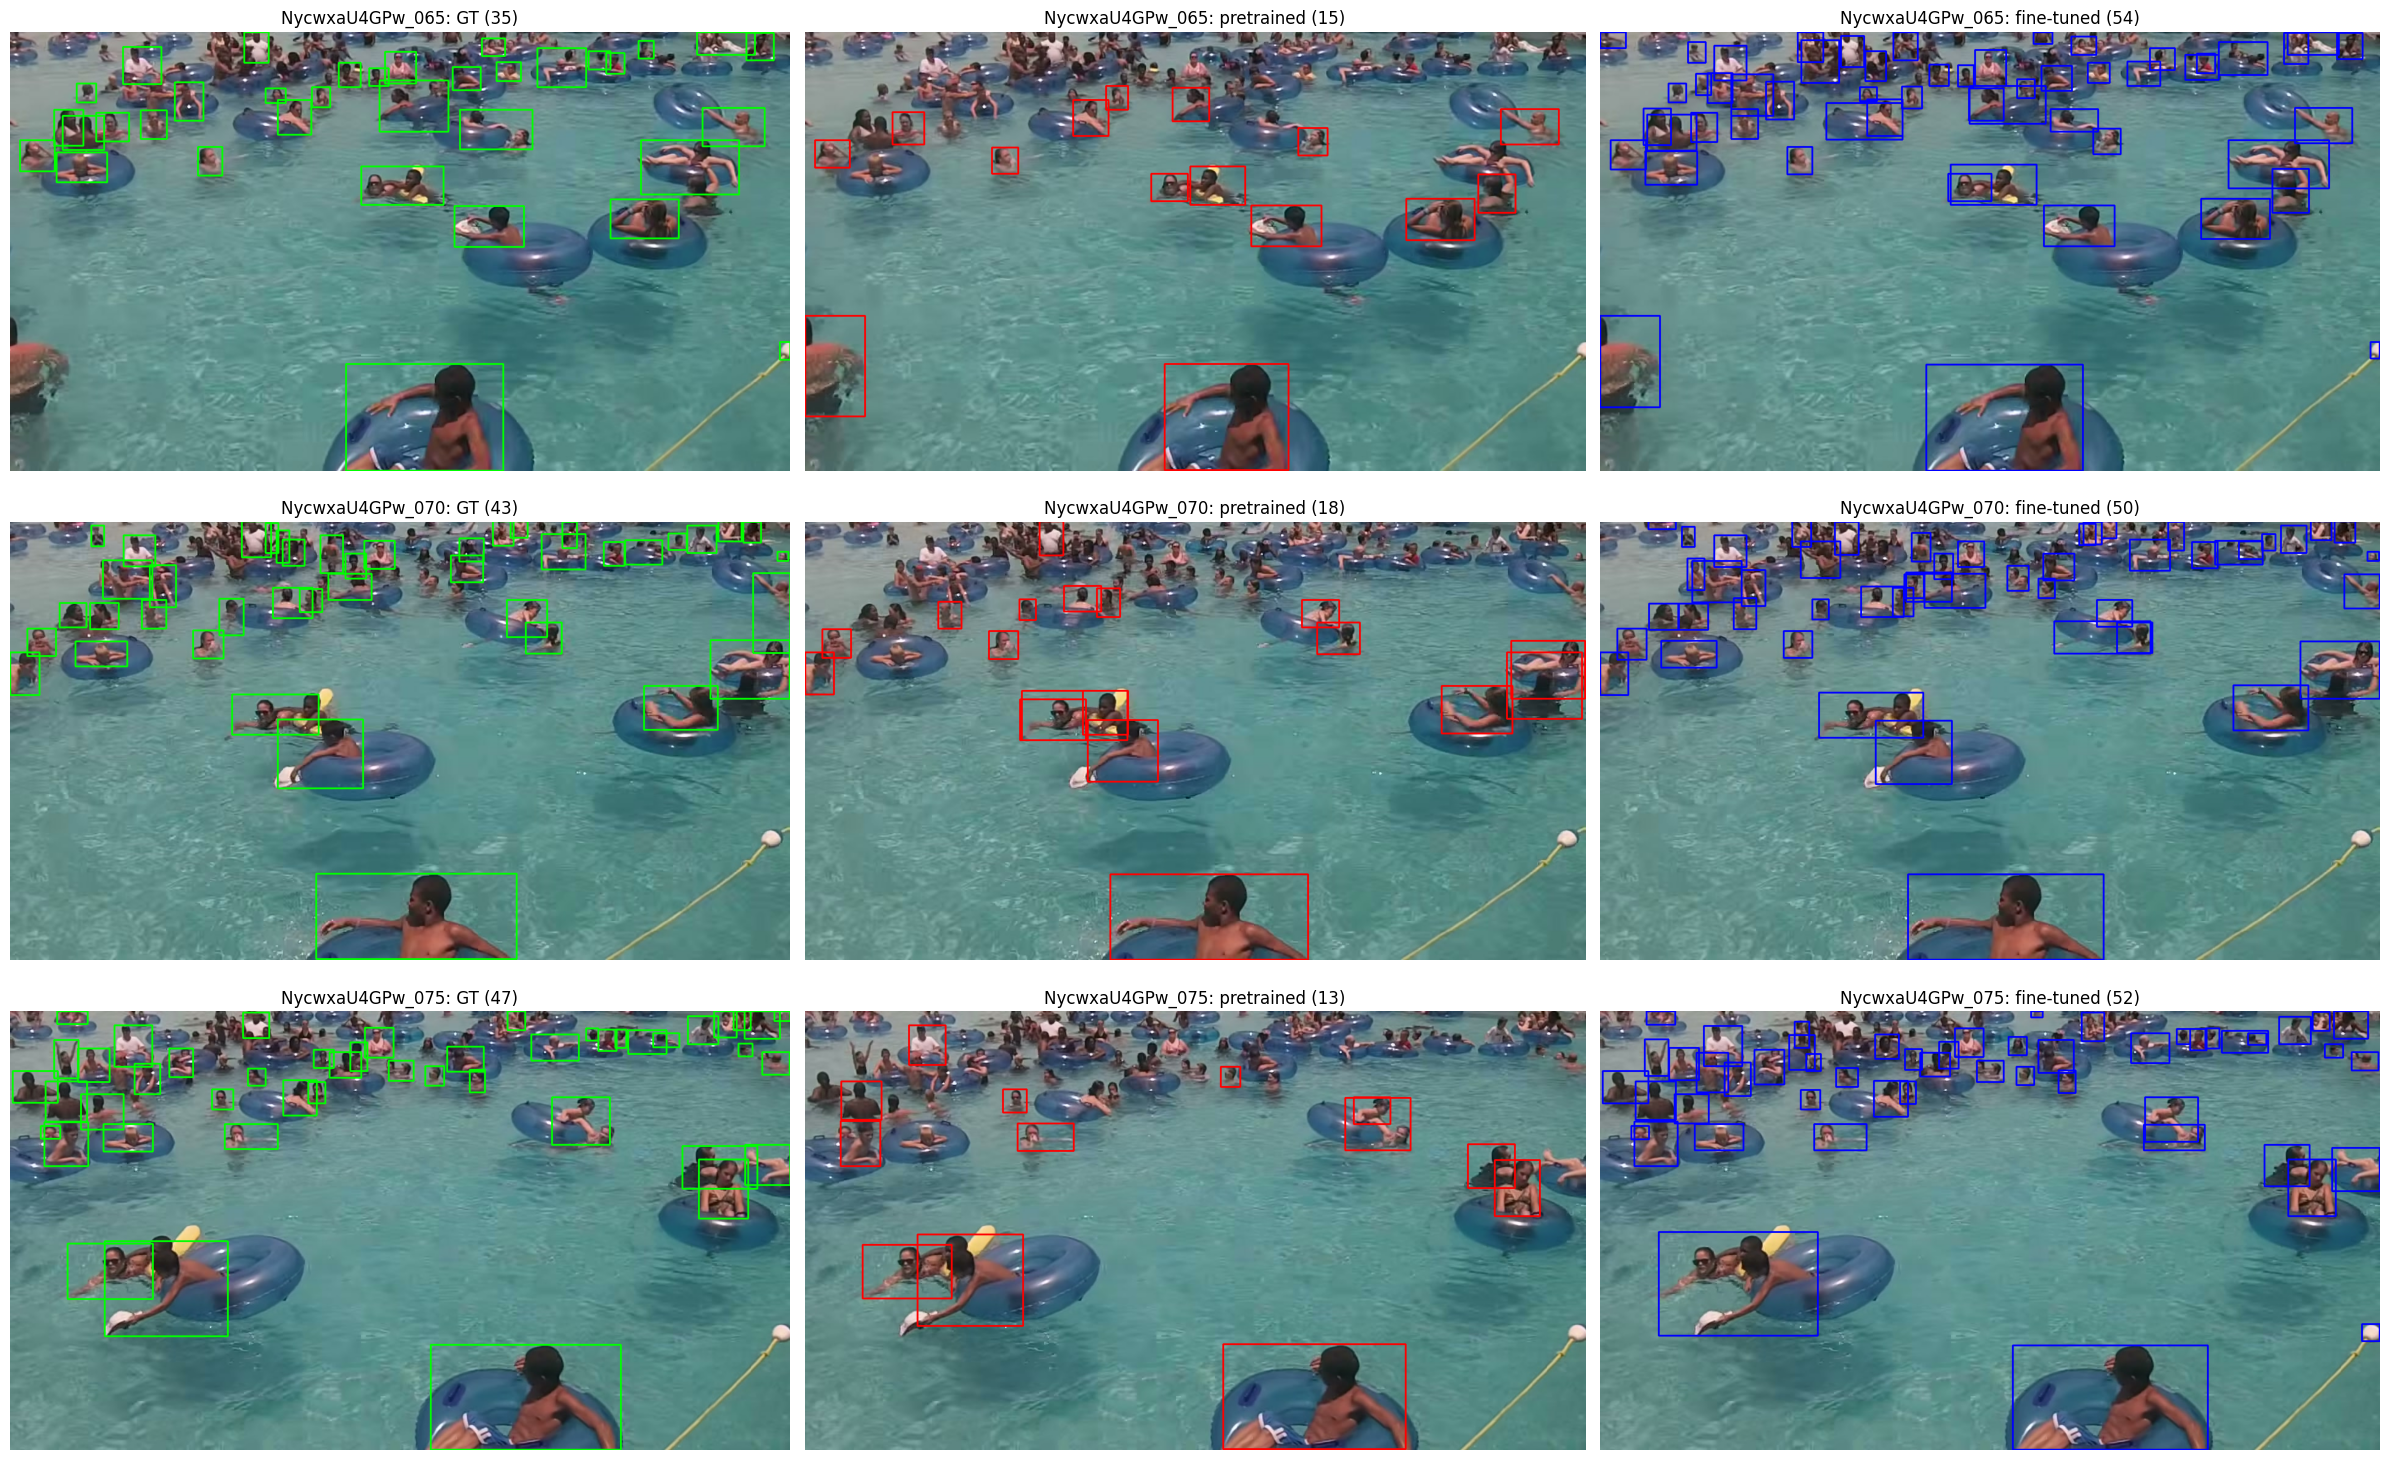

In [13]:
# 8. Side-by-side: ground truth / pretrained / fine-tuned (boxes at OP_CONF)
show = val_stems[:: max(1, len(val_stems) // 3)][:3]
fig, axes = plt.subplots(len(show), 3, figsize=(24, 5 * len(show)), squeeze=False)
for row, s in zip(axes, show):
    img = cv2.imread(str(DATA / "images" / f"{s}.jpg"))
    gt = read_gt(s)
    pb, _ = predict(base, img, 1, OP_CONF)
    fb, _ = predict(ft, img, None, OP_CONF)
    for ax, (title, im) in zip(row, [(f"GT ({len(gt)})", draw(img, gt, (0, 255, 0))),
                                     (f"pretrained ({len(pb)})", draw(img, pb, (0, 0, 255))),
                                     (f"fine-tuned ({len(fb)})", draw(img, fb, (255, 0, 0)))]):
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax.set_title(f"{s}: {title}"); ax.axis("off")
plt.tight_layout(); plt.show()

In [14]:
# 9. Save the best checkpoint and metrics to Drive
import json

DRIVE_OUT.mkdir(parents=True, exist_ok=True)
shutil.copy(OUT / "checkpoint_best_total.pth", DRIVE_OUT / "rfdetr_s_person_best.pth")
(DRIVE_OUT / "metrics.json").write_text(json.dumps(
    {"split": {k: v for k, v in split.items()}, "resolution": RESOLUTION, "results": [res_base, res_ft]}, indent=2))
!ls -la {DRIVE_OUT}

ls: cannot access '/content/drive/MyDrive/RT_DETR_S': No such file or directory
ls: cannot access 'finetuning/outputs': No such file or directory


In [15]:
!ls -la "{DRIVE_OUT}"

total 124503
drwx------ 2 root root      4096 Sep 27 04:42 .
drwx------ 5 root root      4096 Sep 27 04:42 ..
-rw------- 1 root root      2445 Sep 27 04:42 metrics.json
-rw------- 1 root root 127479729 Sep 27 04:42 rfdetr_s_person_best.pth


In [16]:
from rfdetr import RFDETRSmall
model = RFDETRSmall.from_checkpoint("/content/drive/MyDrive/RT_DETR_S finetuning/outputs/rfdetr_s_person_best.pth")

[2026-09-27 04:44:28] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-27 04:44:28] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
